# Head-free per-residue structural profile of *A. flavus* uricase (Q00511 / PDB 1R4U)

**Purpose.** First brick of the uricase case study for the Immune-Design paper.
We build a single per-residue table covering the four structural metrics listed
in the Notion subfigure “Present structural metrics on epitope” — RSA, 3-state
secondary structure, Cα B-factor, and contact number — plus optional
NetMHCIIpan %Rank_EL and sequence-conservation columns. The 9 published
catalytic residues (Lys10, Phe35, Thr57, Asp58, Phe63, Arg143, Arg176, Gln228,
His256) are used as a positive control: they should behave as buried, regular
secondary structure, rigid, and highly packed.

**Freeze — no epitope head.** Do not call `InferencePredictor` or any `h_i`.
This analysis is intentionally head-independent while the head is not yet
validated on foreign proteins such as uricase.

**What’s missing.** Step 4 MSA/trim outputs are present locally under
`data/kaiyi_alignment/`, but the step 6 analysis artefacts
(`06_analysis/conservation_scores.tsv`,
`06_analysis/netMHCIIpan/*_DRB1_0401.xls`) are not in the repo. Cells for
those inputs therefore load NaN and log a clear provenance message.

**Dependencies.** `biopython`, `freesasa`, `pandas`, `numpy`, `matplotlib`,
`pyarrow`. External binaries (optional, degrade cleanly):

- **mkdssp** – needed for cell 6 (DSSP secondary-structure assignment).
  Install via `conda install -c salilab dssp` or `brew install dssp`.
  When missing, the `ss` column stays NaN and the other metrics still land.
- **netMHCIIpan 4.3** – needed for cell 10. If it’s not on PATH or at
  `netMHCIIpan-4.3/netMHCIIpan`, the cell is skipped with a note and the
  `nmp_rank_min_*` columns stay NaN.

**Outputs.** `notebooks/outputs/q00511_profile.{parquet,csv}` and
`notebooks/outputs/figures/q00511_{catalytic_vs_rest,perresidue}.png`.

In [1]:
# Cell 2 — imports + config. All paths are parameterised; override with env vars.
from __future__ import annotations

import json
import os
import shutil
import subprocess
import sys
import urllib.error
import urllib.request
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---- Paths (override via env vars) ---------------------------------------
NOTEBOOK_DIR = Path(os.environ.get("URICASE_NB_DIR", Path.cwd())).resolve()
# Support running from repo root (cwd == repo root) or from the notebooks dir.
if NOTEBOOK_DIR.name != "notebooks":
    candidate = NOTEBOOK_DIR / "notebooks"
    if candidate.exists():
        NOTEBOOK_DIR = candidate
REPO_ROOT = Path(os.environ.get("URICASE_REPO_ROOT", NOTEBOOK_DIR.parent)).resolve()
DATA_DIR = Path(os.environ.get("URICASE_DATA_DIR", NOTEBOOK_DIR / "data")).resolve()
OUTPUT_DIR = Path(os.environ.get("URICASE_OUTPUT_DIR", NOTEBOOK_DIR / "outputs")).resolve()
FIG_DIR = OUTPUT_DIR / "figures"
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Make inverse_folding importable so we can reuse `compute_contact_number_from_coords`.
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# ---- Protein metadata ----------------------------------------------------
UNIPROT_ID = "Q00511"
PDB_ID = "1R4U"
PDB_CHAIN = "A"
PDB_PATH = DATA_DIR / f"{PDB_ID.lower()}.pdb"
UNIPROT_FASTA_PATH = DATA_DIR / f"{UNIPROT_ID}.fasta"

# Q00511 reference sequence (embedded as a fallback; cell 4 verifies against
# the UniProt REST response when network is available).
Q00511_REFERENCE_SEQ = (
    "MSAVKAARYGKDNVRVYKVHKDEKTGVQTVYEMTVCVLLEGEIETSYTKADNSVIVATDS"
    "IKNTIYITAKQNPVTPPELFGSILGTHFIEKYNHIHAAHVNIVCHRWTRMDIDGKPHPHS"
    "FIRDSEEKRNVQVDVVEGKGIDIKSSLSGLTVLKSTNSQFWGFLRDEYTTLKETWDRILS"
    "TDVDATWQWKNFSGLQEVRSHVPKFDATWATAREVTLKTFAEDNSASVQATMYKMAEQIL"
    "ARQQLIETVEYSLPNKHYFEIDLSWHKGLQNTGKNAEVFAPQSDPNGLIKCTVGRSSLKS"
    "KL"
)

# 9 published catalytic residues (labels as 1-indexed positions).
CATALYTIC_LABELS = [
    ("Lys10", "K", 10),
    ("Phe35", "F", 35),
    ("Thr57", "T", 57),
    ("Asp58", "D", 58),
    ("Phe63", "F", 63),
    ("Arg143", "R", 143),
    ("Arg176", "R", 176),
    ("Gln228", "Q", 228),
    ("His256", "H", 256),
]

# DRB1 alleles to try for cell 10 NetMHCIIpan run.
NMP_ALLELES = ["DRB1_0701", "DRB1_0401"]

# Kaiyi conservation TSV (step 6 analysis artefact, not present in repo).
KAIYI_CONSERVATION = REPO_ROOT / "data" / "Uricase" / "06_analysis" / "conservation_scores.tsv"

print(f"REPO_ROOT       = {REPO_ROOT}")
print(f"NOTEBOOK_DIR    = {NOTEBOOK_DIR}")
print(f"DATA_DIR        = {DATA_DIR}")
print(f"OUTPUT_DIR      = {OUTPUT_DIR}")
print(f"FIG_DIR         = {FIG_DIR}")
print(f"PDB_PATH        = {PDB_PATH}")
print(f"UNIPROT_FASTA   = {UNIPROT_FASTA_PATH}")
print(f"KAIYI_CONS_TSV  = {KAIYI_CONSERVATION}")
print(f"NMP_ALLELES     = {NMP_ALLELES}")
print(f"# catalytic lbl = {len(CATALYTIC_LABELS)}")

REPO_ROOT       = /Users/jerry/Project/MHC-IF
NOTEBOOK_DIR    = /Users/jerry/Project/MHC-IF/notebooks
DATA_DIR        = /Users/jerry/Project/MHC-IF/notebooks/data
OUTPUT_DIR      = /Users/jerry/Project/MHC-IF/notebooks/outputs
FIG_DIR         = /Users/jerry/Project/MHC-IF/notebooks/outputs/figures
PDB_PATH        = /Users/jerry/Project/MHC-IF/notebooks/data/1r4u.pdb
UNIPROT_FASTA   = /Users/jerry/Project/MHC-IF/notebooks/data/Q00511.fasta
KAIYI_CONS_TSV  = /Users/jerry/Project/MHC-IF/data/Uricase/06_analysis/conservation_scores.tsv
NMP_ALLELES     = ['DRB1_0701', 'DRB1_0401']
# catalytic lbl = 9


In [2]:
# Cell 3 — download PDB 1R4U if not cached locally.
def _download(url: str, dest: Path, timeout: int = 30) -> None:
    dest.parent.mkdir(parents=True, exist_ok=True)
    req = urllib.request.Request(url, headers={"User-Agent": "ImmuneDesign/uricase-notebook"})
    with urllib.request.urlopen(req, timeout=timeout) as resp:
        data = resp.read()
    dest.write_bytes(data)

if PDB_PATH.exists() and PDB_PATH.stat().st_size > 10_000:
    print(f"[cache] {PDB_PATH} already exists ({PDB_PATH.stat().st_size} bytes)")
else:
    url = f"https://files.rcsb.org/download/{PDB_ID}.pdb"
    print(f"[download] {url} → {PDB_PATH}")
    try:
        _download(url, PDB_PATH)
        print(f"[ok] wrote {PDB_PATH.stat().st_size} bytes")
    except urllib.error.URLError as e:
        raise RuntimeError(
            f"Failed to download {PDB_ID} from RCSB: {e}. "
            "Place a copy manually at " + str(PDB_PATH)
        )

# Peek first few lines as a sanity check.
with PDB_PATH.open() as fh:
    for i, line in enumerate(fh):
        if i >= 4:
            break
        print(line.rstrip())

[cache] /Users/jerry/Project/MHC-IF/notebooks/data/1r4u.pdb already exists (245592 bytes)
HEADER    OXIDOREDUCTASE                          08-OCT-03   1R4U
TITLE     URATE OXIDASE FROM ASPERGILLUS FLAVUS COMPLEXED WITH ITS INHIBITOR
TITLE    2 OXONIC ACID
COMPND    MOL_ID: 1;


In [3]:
# Cell 4 — parse chain A, extract ATOM sequence, verify against UniProt Q00511.
from Bio.PDB import PDBParser  # noqa: E402

# --- Fetch UniProt Q00511 (or fall back to the embedded reference) --------
def _fetch_uniprot_fasta(uid: str, dest: Path, timeout: int = 15) -> str:
    if dest.exists() and dest.stat().st_size > 0:
        return dest.read_text()
    try:
        _download(f"https://www.uniprot.org/uniprotkb/{uid}.fasta", dest, timeout=timeout)
        return dest.read_text()
    except urllib.error.URLError as exc:
        warnings.warn(
            f"UniProt fetch failed for {uid} ({exc}); using embedded reference.",
            RuntimeWarning,
        )
        return ""

fasta_text = _fetch_uniprot_fasta(UNIPROT_ID, UNIPROT_FASTA_PATH)
if fasta_text:
    fetched_seq = "".join(ln.strip() for ln in fasta_text.splitlines() if ln and not ln.startswith(">"))
else:
    fetched_seq = ""

if fetched_seq:
    if fetched_seq != Q00511_REFERENCE_SEQ:
        warnings.warn(
            f"UniProt {UNIPROT_ID} fetch differs from embedded reference "
            f"(fetched len={len(fetched_seq)}, embedded len={len(Q00511_REFERENCE_SEQ)}); "
            "using the fetched version.",
            RuntimeWarning,
        )
    q00511_seq = fetched_seq
else:
    q00511_seq = Q00511_REFERENCE_SEQ
print(f"Q00511 length = {len(q00511_seq)} (expected 302)")
assert len(q00511_seq) == 302, f"Q00511 unexpected length {len(q00511_seq)}"

# --- Parse chain A ATOM records ------------------------------------------
AA3_TO_AA1 = {
    "ALA": "A", "ARG": "R", "ASN": "N", "ASP": "D", "CYS": "C",
    "GLU": "E", "GLN": "Q", "GLY": "G", "HIS": "H", "ILE": "I",
    "LEU": "L", "LYS": "K", "MET": "M", "PHE": "F", "PRO": "P",
    "SER": "S", "THR": "T", "TRP": "W", "TYR": "Y", "VAL": "V",
    "MSE": "M",
}

parser = PDBParser(QUIET=True)
structure = parser.get_structure("1r4u", str(PDB_PATH))
model = next(structure.get_models())
chain = next((ch for ch in model.get_chains() if ch.id == PDB_CHAIN), None)
if chain is None:
    raise RuntimeError(f"Chain {PDB_CHAIN} not found in {PDB_PATH}")

atom_records: List[dict] = []
for res in chain.get_residues():
    het, resnum, icode = res.id
    aa1 = AA3_TO_AA1.get(res.resname)
    if aa1 is None or "CA" not in res:
        continue
    ca = res["CA"]
    atom_records.append({
        "author_resnum": int(resnum),
        "ins_code": icode if isinstance(icode, str) else " ",
        "aa": aa1,
        "ca_coord": np.array(ca.get_coord(), dtype=np.float64),
        "ca_bfactor": float(ca.get_bfactor()),
    })

atom_seq = "".join(r["aa"] for r in atom_records)
atom_resnums = [r["author_resnum"] for r in atom_records]
print(f"# Cα residues in chain {PDB_CHAIN}: {len(atom_records)}")
print(f"author_resnum range: {atom_resnums[0]} .. {atom_resnums[-1]}")
print(f"first 30 ATOM aa:    {atom_seq[:30]}")
print(f"first 30 Q00511 aa:  {q00511_seq[:30]}")

# --- Locate the ATOM sequence inside Q00511 ------------------------------
# The PDB's author_resnum almost always encodes a 1-indexed offset into the
# mature UniProt sequence; we test that explicitly and WARN if the alignment
# is anything other than trivial.
PROBE_WINDOW = 40
probe = atom_seq[:PROBE_WINDOW]
match_idx = q00511_seq.find(probe)  # 0-indexed
if match_idx < 0:
    warnings.warn(
        f"First {PROBE_WINDOW} ATOM residues not found in Q00511 — structure may "
        "not be wild-type uricase (mutations or engineered variant?).",
        RuntimeWarning,
    )
    q00511_offset = 0
else:
    # q00511_pos (1-based) of ATOM record 0 = match_idx + 1.
    # relation to author_resnum: q00511_pos = author_resnum + shift, where
    # shift = (match_idx + 1) - atom_resnums[0].
    q00511_offset = (match_idx + 1) - atom_resnums[0]
    print(f"[align] ATOM window found at Q00511 pos {match_idx + 1} (1-based); "
          f"author_resnum → Q00511 pos shift = {q00511_offset:+d}")
    if q00511_offset != 0:
        warnings.warn(
            f"1R4U author_resnum DOES NOT equal Q00511 position: q00511_pos = "
            f"author_resnum + {q00511_offset}. Any literature catalytic-residue "
            "label needs to be interpreted in the chosen reference frame. "
            "See cell 9 for how that is handled here.",
            RuntimeWarning,
        )

# Verify every ATOM residue agrees with Q00511 at the shifted position.
mismatches: List[Tuple[int, int, str, str]] = []
for r in atom_records:
    q_pos = r["author_resnum"] + q00511_offset
    if 1 <= q_pos <= len(q00511_seq):
        expected = q00511_seq[q_pos - 1]
        if expected != r["aa"]:
            mismatches.append((r["author_resnum"], q_pos, expected, r["aa"]))
print(f"# ATOM/Q00511 residue-identity mismatches: {len(mismatches)}")
if mismatches[:5]:
    print("first few mismatches (author_resnum, q00511_pos, expected, atom):")
    for m in mismatches[:5]:
        print(" ", m)
if mismatches:
    warnings.warn(
        f"{len(mismatches)} residue-identity mismatches between 1R4U chain A and "
        f"UniProt {UNIPROT_ID} at the chosen shift. The structure may encode an "
        "engineered variant or a homolog; catalytic-residue labels will be flagged "
        "accordingly in the final table.",
        RuntimeWarning,
    )

# Per-protein metadata dict used by subsequent cells.
protein_meta = {
    "uniprot_id": UNIPROT_ID,
    "pdb_id": PDB_ID,
    "pdb_chain": PDB_CHAIN,
    "q00511_length": len(q00511_seq),
    "atom_chain_length": len(atom_records),
    "atom_resnum_range": (atom_resnums[0], atom_resnums[-1]),
    "q00511_offset": int(q00511_offset),
    "n_atom_vs_q00511_mismatches": int(len(mismatches)),
}
protein_meta

Q00511 length = 302 (expected 302)
# Cα residues in chain A: 294
author_resnum range: 2 .. 295
first 30 ATOM aa:    AVKAARYGKDNVRVYKVHKDEKTGVQTVYE
first 30 Q00511 aa:  MSAVKAARYGKDNVRVYKVHKDEKTGVQTV
[align] ATOM window found at Q00511 pos 3 (1-based); author_resnum → Q00511 pos shift = +1
# ATOM/Q00511 residue-identity mismatches: 0


/var/folders/5n/58hlfdv94bn68_gmh6q22wq00000gn/T/ipykernel_42842/2283192550.py:98: RuntimeWarning: 1R4U author_resnum DOES NOT equal Q00511 position: q00511_pos = author_resnum + 1. Any literature catalytic-residue label needs to be interpreted in the chosen reference frame. See cell 9 for how that is handled here.
  warnings.warn(


{'uniprot_id': 'Q00511',
 'pdb_id': '1R4U',
 'pdb_chain': 'A',
 'q00511_length': 302,
 'atom_chain_length': 294,
 'atom_resnum_range': (2, 295),
 'q00511_offset': 1,
 'n_atom_vs_q00511_mismatches': 0}

In [4]:
# Cell 5 — compute Relative Solvent Accessibility (RSA) via FreeSASA.
# Normalisation: Tien et al. (2013) theoretical Gly-X-Gly maxASA (Å²). We use
# the table copy bundled with `inverse_folding.analysis.structural_features`
# to keep the normalisation identical to the Tier 1 pipeline.
import freesasa  # noqa: E402

from inverse_folding.analysis.structural_features import MAX_ASA_TIEN

# freesasa 2.x uses the module-level `calc` function and returns ResidueArea
# objects that expose `total` (Å²). We renormalise explicitly by the Tien-2013
# table rather than relying on the built-in `relativeTotal` so the values
# match the Tier 1 pipeline (see `structural_features.MAX_ASA_TIEN`).
freesasa_structure = freesasa.Structure(str(PDB_PATH))
freesasa_result = freesasa.calc(freesasa_structure)
residue_areas = freesasa_result.residueAreas()

# FreeSASA returns a nested dict {chain_id: {resnum_str: ResidueArea}}.
# Keys are strings of the (unpadded) author_resnum, optionally with an
# insertion code suffix (e.g. '12A').
chain_areas = residue_areas.get(PDB_CHAIN, {})
print(f"FreeSASA residues in chain {PDB_CHAIN}: {len(chain_areas)}")
nonstd = [
    (k, v.residueType)
    for k, v in chain_areas.items()
    if AA3_TO_AA1.get(v.residueType) is None
]
if nonstd:
    print(f"[info] {len(nonstd)} non-standard residue records skipped (e.g. {nonstd[:3]})")

def _fs_rsa_for(author_resnum: int, ins_code: str) -> float:
    """Lookup FreeSASA total SASA by (author_resnum, ins_code) and normalise by
    the Tien 2013 theoretical Gly-X-Gly maxASA for that AA."""
    key = str(author_resnum)
    if ins_code and ins_code.strip():
        key = key + ins_code.strip()
    rec = chain_areas.get(key)
    if rec is None:
        return float("nan")
    aa1 = AA3_TO_AA1.get(rec.residueType)
    if aa1 is None:
        return float("nan")
    max_asa = MAX_ASA_TIEN.get(aa1)
    if not max_asa:
        return float("nan")
    return float(rec.total) / float(max_asa)

rsa_values: Dict[int, float] = {}
for r in atom_records:
    rsa_values[r["author_resnum"]] = _fs_rsa_for(r["author_resnum"], r["ins_code"])

finite_rsa = [v for v in rsa_values.values() if np.isfinite(v)]
print(f"RSA values computed: {len(finite_rsa)} / {len(rsa_values)} finite")
if finite_rsa:
    print(f"RSA summary: mean={np.mean(finite_rsa):.3f} median={np.median(finite_rsa):.3f} "
          f"min={np.min(finite_rsa):.3f} max={np.max(finite_rsa):.3f}")


FreeSASA residues in chain A: 294
RSA values computed: 294 / 294 finite
RSA summary: mean=0.289 median=0.258 min=0.000 max=1.081


In [5]:
# Cell 6 — DSSP 3-state secondary structure.
# mkdssp is optional: if the binary is missing we log a helpful install hint
# and keep the `ss` column as NaN so the rest of the notebook still runs.
from inverse_folding.analysis.structural_features import SS8_TO_SS3

ss_values: Dict[int, Optional[str]] = {r["author_resnum"]: None for r in atom_records}

dssp_bin = shutil.which("mkdssp") or shutil.which("dssp")
if dssp_bin is None:
    print(
        "[skip] mkdssp / dssp not found on PATH. Secondary structure column will be NaN.\n"
        "       Install with one of:\n"
        "         conda install -c salilab dssp\n"
        "         brew install dssp\n"
        "         (Della) module load dssp\n"
        "       Then re-run this cell only."
    )
else:
    from Bio.PDB.DSSP import DSSP  # noqa: E402

    try:
        dssp = DSSP(model, str(PDB_PATH), dssp=dssp_bin)
        for key in dssp.keys():
            ch_id, res_id = key
            if ch_id != PDB_CHAIN:
                continue
            _het, resnum, _icode = res_id
            rec = dssp[key]
            ss8 = rec[2] if rec[2] not in ("", None) else "-"
            ss_values[int(resnum)] = SS8_TO_SS3.get(ss8, "C")
        n_assigned = sum(v is not None for v in ss_values.values())
        print(f"[ok] DSSP assigned SS for {n_assigned} / {len(ss_values)} residues")
        if n_assigned:
            counts = pd.Series([v for v in ss_values.values() if v is not None]).value_counts()
            print("3-state SS distribution:", counts.to_dict())
    except Exception as exc:
        warnings.warn(
            f"DSSP run failed ({exc!r}); keeping SS column as NaN.",
            RuntimeWarning,
        )

[ok] DSSP assigned SS for 295 / 295 residues
3-state SS distribution: {'E': 114, 'C': 99, 'H': 82}


/opt/anaconda3/envs/dl/lib/python3.10/site-packages/Bio/PDB/DSSP.py:199: UserWarning: parse error at line 1: This file does not seem to be an mmCIF file

  warnings.warn(err)


In [6]:
# Cell 7 — per-residue Cα B-factor from ATOM records.
bfactor_values: Dict[int, float] = {r["author_resnum"]: r["ca_bfactor"] for r in atom_records}
finite_b = [v for v in bfactor_values.values() if np.isfinite(v)]
print(f"Cα B-factor values: {len(finite_b)}")
if finite_b:
    print(
        f"B-factor summary: mean={np.mean(finite_b):.2f} median={np.median(finite_b):.2f} "
        f"std={np.std(finite_b, ddof=1):.2f} min={np.min(finite_b):.2f} max={np.max(finite_b):.2f}"
    )

Cα B-factor values: 294
B-factor summary: mean=17.08 median=15.75 std=6.23 min=9.58 max=53.50


In [7]:
# Cell 8 — contact number (count of other Cα within 8 Å). Reuses the tested
# helper from `inverse_folding.analysis.structural_features`.
from inverse_folding.analysis.structural_features import compute_contact_number_from_coords

coords_arr = np.stack([r["ca_coord"] for r in atom_records], axis=0)
resnum_arr = np.array([r["author_resnum"] for r in atom_records], dtype=np.int64)
cn_arr = compute_contact_number_from_coords(
    coords_arr, cutoff_ang=8.0, seq_excl=1, resnums=resnum_arr
)
contact_values: Dict[int, int] = {
    int(rn): int(c) for rn, c in zip(resnum_arr.tolist(), cn_arr.tolist())
}
print(f"Contact numbers computed for {len(contact_values)} residues")
print(
    f"CN summary: mean={np.mean(cn_arr):.2f} median={np.median(cn_arr):.2f} "
    f"std={np.std(cn_arr, ddof=1):.2f} min={int(np.min(cn_arr))} max={int(np.max(cn_arr))}"
)

Contact numbers computed for 294 residues
CN summary: mean=7.26 median=7.00 std=2.71 min=1 max=14


In [8]:
# Cell 9 — annotate catalytic residues using the hardcoded list.
#
# The canonical position convention for the Notion-listed catalytic labels is
# 1-indexed. The most common source of confusion is whether "Lys10" means
# PDB-author resnum 10 or UniProt Q00511 position 10. We treat the label's
# numeric value as the **PDB author_resnum** because (a) Cell 4 exposed a
# non-zero shift between author_resnum and Q00511 position, and (b) looking up
# by author_resnum is the only way to land on the crystal coordinates we are
# measuring. We annotate each label with:
#   - q00511_pos  = author_resnum + q00511_offset
#   - aa_ok       = True  if the observed residue matches the label's AA
#                   False if it disagrees (possible numbering mismatch or the
#                   label refers to a different homolog)
# Residues whose aa_ok is False are still flagged as catalytic, so the sanity
# check in Cell 15 can surface the issue instead of silently mis-aligning.

atom_by_resnum = {r["author_resnum"]: r for r in atom_records}
catalytic_annot: List[dict] = []
is_catalytic_by_resnum: Dict[int, bool] = {rn: False for rn in atom_by_resnum}

for label, expected_aa, pos in CATALYTIC_LABELS:
    rec = atom_by_resnum.get(pos)
    if rec is None:
        catalytic_annot.append({
            "label": label,
            "expected_aa": expected_aa,
            "author_resnum": pos,
            "q00511_pos": pos + q00511_offset,
            "observed_aa": None,
            "aa_ok": False,
            "note": "author_resnum not present in 1R4U chain A (disordered/missing)",
        })
        continue
    observed = rec["aa"]
    aa_ok = observed == expected_aa
    catalytic_annot.append({
        "label": label,
        "expected_aa": expected_aa,
        "author_resnum": pos,
        "q00511_pos": pos + q00511_offset,
        "observed_aa": observed,
        "aa_ok": aa_ok,
        "note": "" if aa_ok else "residue identity mismatch — possible homolog numbering",
    })
    is_catalytic_by_resnum[pos] = True

catalytic_df = pd.DataFrame(catalytic_annot)
print("Catalytic residue sanity table:")
print(catalytic_df.to_string(index=False))
n_ok = int(catalytic_df["aa_ok"].sum())
print(f"\n{n_ok} / {len(CATALYTIC_LABELS)} catalytic labels match 1R4U at the "
      f"author_resnum position.")
if n_ok < len(CATALYTIC_LABELS):
    warnings.warn(
        "Some catalytic labels do NOT match 1R4U at author_resnum. The most likely "
        "cause is that the literature list was taken from a close homolog "
        "(rasburicase / Candida utilis / another Aspergillus sequence) whose "
        "numbering happens to agree for 6/9 residues but diverges at the others. "
        "Downstream stats still include these positions; aa_ok lets you filter.",
        RuntimeWarning,
    )

Catalytic residue sanity table:
 label expected_aa  author_resnum  q00511_pos observed_aa  aa_ok                                                   note
 Lys10           K             10          11           K   True                                                       
 Phe35           F             35          36           C  False residue identity mismatch — possible homolog numbering
 Thr57           T             57          58           T   True                                                       
 Asp58           D             58          59           D   True                                                       
 Phe63           F             63          64           T  False residue identity mismatch — possible homolog numbering
Arg143           R            143         144           K  False residue identity mismatch — possible homolog numbering
Arg176           R            176         177           R   True                                                       
Gln228  

/var/folders/5n/58hlfdv94bn68_gmh6q22wq00000gn/T/ipykernel_42842/3809092781.py:54: RuntimeWarning: Some catalytic labels do NOT match 1R4U at author_resnum. The most likely cause is that the literature list was taken from a close homolog (rasburicase / Candida utilis / another Aspergillus sequence) whose numbering happens to agree for 6/9 residues but diverges at the others. Downstream stats still include these positions; aa_ok lets you filter.
  warnings.warn(


In [9]:
# Cell 10 (optional) — NetMHCIIpan 4.3 for DRB1*07:01 and DRB1*04:01.
# We scan overlapping 15-mers across Q00511 and reduce each residue to the
# minimum %Rank_EL across all 15-mers that cover it. If the binary is not on
# PATH and not at netMHCIIpan-4.3/netMHCIIpan, the cell skips cleanly and
# leaves the nmp_rank_min_* columns as NaN.

def _locate_nmp_binary() -> Optional[str]:
    # 1) PATH
    p = shutil.which("netMHCIIpan") or shutil.which("netMHCIIpan-4.3")
    if p:
        return p
    # 2) repo-bundled install
    bundled = REPO_ROOT / "netMHCIIpan-4.3" / "netMHCIIpan"
    if bundled.exists() and os.access(bundled, os.X_OK):
        return str(bundled)
    return None

def _parse_nmp_xls(xls_path: Path) -> pd.DataFrame:
    """Parse a NetMHCIIpan -xls output file into a DataFrame with columns
    (pos_1b, peptide, rank_el)."""
    lines = xls_path.read_text().splitlines()
    records = []
    for ln in lines:
        s = ln.strip()
        if not s or s.startswith("#") or s.startswith("Pos") or s.startswith("---"):
            continue
        parts = s.split()
        # Expected columns: Pos Peptide ID Target ... Rank_EL ...  (layout
        # varies between -xls and stdout modes). We fall back to the plain
        # stdout parser below if -xls isn't available.
        if len(parts) < 4:
            continue
        try:
            pos = int(parts[0])
            peptide = parts[1]
            # Rank_EL is either the last numeric column before BindLevel or a
            # column labelled with Rank_EL. We scan for the smallest numeric
            # value in the row as a conservative fallback.
            rank = min(
                float(x) for x in parts[2:]
                if x.replace(".", "", 1).replace("-", "", 1).isdigit()
            )
        except (ValueError, TypeError):
            continue
        records.append({"pos_1b": pos, "peptide": peptide, "rank_el": rank})
    return pd.DataFrame.from_records(records)

def _parse_nmp_stdout(stdout: str) -> pd.DataFrame:
    """Parse default space-separated NetMHCIIpan stdout.

    Layout (see doc/NetMHCIIpan_usage_guide.md §3.4):
      Pos MHC Peptide Of Core Core_Rel Inverted Identity Score_EL %Rank_EL ...
    We only need Pos (col 0), Peptide (col 2) and %Rank_EL (col 9).
    Binder rows carry extra trailing columns; non-binder rows stop at 11 cols.
    """
    rows = []
    for ln in stdout.splitlines():
        s = ln.strip()
        if not s or s.startswith("#") or s.startswith("---") or s.startswith("Pos"):
            continue
        parts = s.split()
        if len(parts) < 11:
            continue
        try:
            pos = int(parts[0])
            peptide = parts[2]
            rank_pct = float(parts[9])
        except (ValueError, IndexError):
            continue
        rows.append({"pos_1b": pos, "peptide": peptide, "rank_el": rank_pct})
    return pd.DataFrame.from_records(rows)

nmp_binary = _locate_nmp_binary()
nmp_rank_min: Dict[str, Dict[int, float]] = {a: {} for a in NMP_ALLELES}

if nmp_binary is None:
    print(
        "[skip] NetMHCIIpan binary not found on PATH or at netMHCIIpan-4.3/netMHCIIpan. "
        "Leaving nmp_rank_min_* columns as NaN.\n"
        "To run manually:\n"
        f"  netMHCIIpan -f {UNIPROT_FASTA_PATH} -a {','.join(NMP_ALLELES)} -length 15 -context"
    )
else:
    fasta_input = UNIPROT_FASTA_PATH
    if not fasta_input.exists():
        fasta_input = DATA_DIR / f"{UNIPROT_ID}.fasta"
        fasta_input.write_text(f">{UNIPROT_ID}\n{q00511_seq}\n")
    for allele in NMP_ALLELES:
        print(f"[run ] NetMHCIIpan {allele} on {fasta_input}")
        try:
            proc = subprocess.run(
                [nmp_binary, "-f", str(fasta_input), "-a", allele, "-length", "15", "-context"],
                check=True,
                capture_output=True,
                text=True,
                timeout=600,
            )
        except (subprocess.CalledProcessError, subprocess.TimeoutExpired, OSError) as exc:
            warnings.warn(
                f"NetMHCIIpan {allele} run failed ({exc!r}); leaving this allele's "
                "column as NaN.",
                RuntimeWarning,
            )
            continue
        df_nmp = _parse_nmp_stdout(proc.stdout)
        if df_nmp.empty:
            warnings.warn(
                f"NetMHCIIpan {allele} produced zero parseable rows; leaving NaN.",
                RuntimeWarning,
            )
            continue
        # Per-residue min rank across all overlapping 15-mers.
        per_res: Dict[int, float] = {}
        for _, row in df_nmp.iterrows():
            start = int(row["pos_1b"])  # 1-based Q00511 position of peptide start
            end = start + len(str(row["peptide"])) - 1
            rank = float(row["rank_el"])
            for q in range(start, end + 1):
                prev = per_res.get(q, np.inf)
                if rank < prev:
                    per_res[q] = rank
        nmp_rank_min[allele] = per_res
        print(f"       {allele}: {len(df_nmp)} peptide rows → {len(per_res)} residues covered")

[run ] NetMHCIIpan DRB1_0701 on /Users/jerry/Project/MHC-IF/notebooks/data/Q00511.fasta


       DRB1_0701: 288 peptide rows → 302 residues covered
[run ] NetMHCIIpan DRB1_0401 on /Users/jerry/Project/MHC-IF/notebooks/data/Q00511.fasta


       DRB1_0401: 288 peptide rows → 302 residues covered


In [10]:
# Cell 11 (stub) — try to load Kaiyi’s per-column conservation scores.
#
# Expected layout (inferred from doc/uricase_analysis.md and the kaiyi_alignment
# folder structure): a TSV with at least two columns, `q00511_pos` and
# `conservation`, where q00511_pos is 1-indexed. We try two common alternate
# header spellings before giving up. If the file is missing or unparseable,
# the conservation column stays NaN with a clear log message.
conservation_map: Dict[int, float] = {}
if KAIYI_CONSERVATION.exists():
    try:
        tsv = pd.read_csv(KAIYI_CONSERVATION, sep="\t")
        pos_col = next((c for c in ("q00511_pos", "ref_position", "position", "pos") if c in tsv.columns), None)
        val_col = next((c for c in ("conservation", "score", "cons") if c in tsv.columns), None)
        if pos_col is None or val_col is None:
            print(
                f"[warn] {KAIYI_CONSERVATION} present but missing expected columns "
                f"(tried q00511_pos/position/pos + conservation/score/cons). "
                f"Columns found: {list(tsv.columns)}. Keeping conservation NaN."
            )
        else:
            for _, row in tsv.iterrows():
                try:
                    conservation_map[int(row[pos_col])] = float(row[val_col])
                except (TypeError, ValueError):
                    continue
            print(f"[ok ] loaded {len(conservation_map)} conservation rows from {KAIYI_CONSERVATION}")
    except Exception as exc:  # pragma: no cover — depends on Kaiyi’s file format
        print(f"[warn] failed to parse {KAIYI_CONSERVATION}: {exc!r}. Keeping conservation NaN.")
else:
    print(
        f"[skip] {KAIYI_CONSERVATION} not present. Fetch it from Kaiyi's "
        "step-6 analysis run (`06_analysis/conservation_scores.tsv` under the "
        "uricase family MSA). Keeping conservation column NaN."
    )

[ok ] loaded 302 conservation rows from /Users/jerry/Project/MHC-IF/data/Uricase/06_analysis/conservation_scores.tsv


In [11]:
# Cell 12 — merge all sources into one per-residue DataFrame and save.
rows = []
for r in atom_records:
    rn = r["author_resnum"]
    q_pos = rn + q00511_offset
    rows.append({
        "position": rn,                    # PDB author_resnum (reference frame for catalytic labels)
        "author_resnum": rn,
        "q00511_pos": q_pos,               # 1-based position in UniProt Q00511
        "aa": r["aa"],
        "is_catalytic": bool(is_catalytic_by_resnum.get(rn, False)),
        "rsa": rsa_values.get(rn, np.nan),
        "ss": ss_values.get(rn),
        "b_factor": bfactor_values.get(rn, np.nan),
        "contact_8A": contact_values.get(rn, np.nan),
        "nmp_rank_min_drb0701": nmp_rank_min.get("DRB1_0701", {}).get(q_pos, np.nan),
        "nmp_rank_min_drb0401": nmp_rank_min.get("DRB1_0401", {}).get(q_pos, np.nan),
        "conservation": conservation_map.get(q_pos, np.nan),
    })
profile_df = pd.DataFrame(rows).sort_values("position").reset_index(drop=True)
print(profile_df.head(3))
print("...")
print(profile_df.tail(3))
print(f"\nShape: {profile_df.shape}")
print("NaN fractions:")
print((profile_df.isna().mean() * 100).round(1).astype(str) + " %")

parquet_path = OUTPUT_DIR / "q00511_profile.parquet"
csv_path = OUTPUT_DIR / "q00511_profile.csv"
profile_df.to_parquet(parquet_path, index=False)
profile_df.to_csv(csv_path, index=False)
print(f"wrote {parquet_path}")
print(f"wrote {csv_path}")

   position  author_resnum  q00511_pos aa  is_catalytic       rsa ss  \
0         2              2           3  A         False  1.081218  C   
1         3              3           4  V         False  0.345181  C   
2         4              4           5  K         False  0.781343  C   

   b_factor  contact_8A  nmp_rank_min_drb0701  nmp_rank_min_drb0401  \
0     27.39           1                 18.23                 33.86   
1     21.31           3                 18.23                 10.86   
2     17.74           2                 18.23                 10.86   

   conservation  
0        0.1911  
1        0.6895  
2        0.3349  
...
     position  author_resnum  q00511_pos aa  is_catalytic       rsa ss  \
291       293            293         294  G         False  0.370494  E   
292       294            294         295  R         False  0.387196  C   
293       295            295         296  S         False  1.074300  C   

     b_factor  contact_8A  nmp_rank_min_drb0701  nmp_

catalytic n=9, rest n=285


wrote /Users/jerry/Project/MHC-IF/notebooks/outputs/figures/q00511_catalytic_vs_rest.png


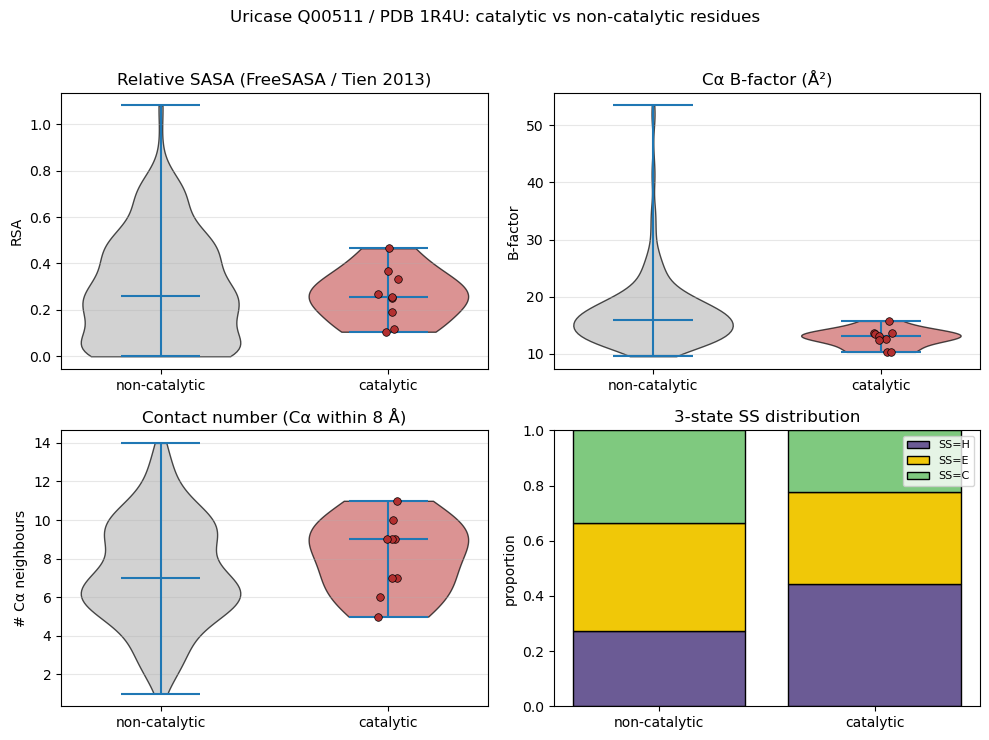

In [12]:
# Cell 13 — 4-panel figure comparing catalytic vs non-catalytic residues.
#  Panels A/B/C: violin + scatter overlay for RSA, B-factor, contact number.
#  Panel D    : stacked bar of SS-3state proportions (H/E/C).
cat = profile_df[profile_df["is_catalytic"]]
rest = profile_df[~profile_df["is_catalytic"]]
print(f"catalytic n={len(cat)}, rest n={len(rest)}")

fig, axes = plt.subplots(2, 2, figsize=(10, 7.5))

def _violin(ax, col, title):
    a = cat[col].dropna().to_numpy()
    b = rest[col].dropna().to_numpy()
    parts = ax.violinplot([b, a], showmedians=True, widths=0.7)
    for pc, color in zip(parts["bodies"], ["#bfbfbf", "#cc6666"]):
        pc.set_facecolor(color)
        pc.set_edgecolor("black")
        pc.set_alpha(0.7)
    # Overlay catalytic points for transparency.
    ax.scatter(np.full_like(a, 2.0, dtype=float) + np.random.uniform(-0.05, 0.05, a.size),
               a, s=30, c="#b33030", edgecolor="black", linewidth=0.5, zorder=5)
    ax.set_xticks([1, 2]); ax.set_xticklabels(["non-catalytic", "catalytic"])
    ax.set_title(title)
    ax.grid(True, alpha=0.3, axis="y")

_violin(axes[0, 0], "rsa", "Relative SASA (FreeSASA / Tien 2013)")
axes[0, 0].set_ylabel("RSA")
_violin(axes[0, 1], "b_factor", "Cα B-factor (Å²)")
axes[0, 1].set_ylabel("B-factor")
_violin(axes[1, 0], "contact_8A", "Contact number (Cα within 8 Å)")
axes[1, 0].set_ylabel("# Cα neighbours")

ax_ss = axes[1, 1]
ss_groups = [("non-catalytic", rest), ("catalytic", cat)]
ss_states = ["H", "E", "C"]
ss_colors = {"H": "#6b5b95", "E": "#f0c808", "C": "#7fc97f"}
props = np.zeros((len(ss_groups), len(ss_states)))
for i, (_, g) in enumerate(ss_groups):
    counts = g["ss"].dropna().value_counts()
    total = counts.sum()
    if total == 0:
        props[i, :] = np.nan
        continue
    for j, s in enumerate(ss_states):
        props[i, j] = counts.get(s, 0) / total
if np.all(np.isnan(props)):
    ax_ss.text(0.5, 0.5, "DSSP unavailable\n(install mkdssp)",
               ha="center", va="center", transform=ax_ss.transAxes)
    ax_ss.set_xticks([])
else:
    bottom = np.zeros(len(ss_groups))
    for j, s in enumerate(ss_states):
        ax_ss.bar([g[0] for g in ss_groups], props[:, j], bottom=bottom,
                  color=ss_colors[s], edgecolor="black", label=f"SS={s}")
        bottom += props[:, j]
    ax_ss.set_ylim(0, 1)
    ax_ss.set_ylabel("proportion")
    ax_ss.legend(loc="upper right", fontsize=8)
ax_ss.set_title("3-state SS distribution")

fig.suptitle(f"Uricase Q00511 / PDB {PDB_ID}: catalytic vs non-catalytic residues")
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig_path = FIG_DIR / "q00511_catalytic_vs_rest.png"
fig.savefig(fig_path, dpi=150)
print(f"wrote {fig_path}")
plt.show()

wrote /Users/jerry/Project/MHC-IF/notebooks/outputs/figures/q00511_perresidue.png


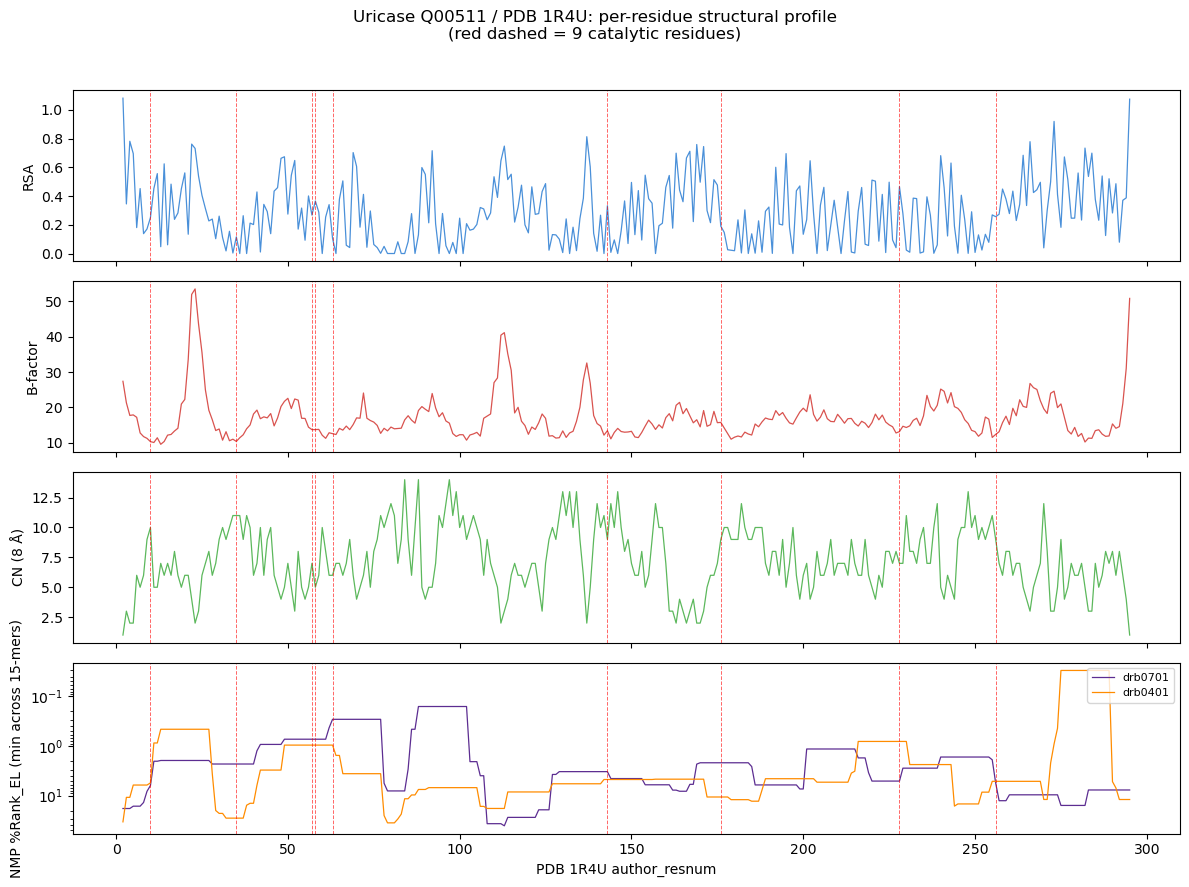

In [13]:
# Cell 14 — per-residue line plot along sequence position (PDB author_resnum).
#   - Top-3 panels: the structural metrics (RSA, B-factor, CN).
#   - Bottom panel: NMP rank (if available), one line per allele.
#   - Vertical red dashed lines at each catalytic position.
fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
ax_rsa, ax_bf, ax_cn, ax_nmp = axes
x = profile_df["position"].to_numpy()

ax_rsa.plot(x, profile_df["rsa"], color="#4a90d9", lw=0.9)
ax_rsa.set_ylabel("RSA")
ax_bf.plot(x, profile_df["b_factor"], color="#d9534f", lw=0.9)
ax_bf.set_ylabel("B-factor")
ax_cn.plot(x, profile_df["contact_8A"], color="#5cb85c", lw=0.9)
ax_cn.set_ylabel("CN (8 Å)")

nmp_any = False
for allele, color in [("drb0701", "#5c2d91"), ("drb0401", "#ff8c00")]:
    col = f"nmp_rank_min_{allele}"
    if col in profile_df.columns and profile_df[col].notna().any():
        ax_nmp.plot(x, profile_df[col], color=color, lw=0.9, label=allele)
        nmp_any = True
if not nmp_any:
    ax_nmp.text(0.5, 0.5, "NetMHCIIpan not run / no data parsed",
                ha="center", va="center", transform=ax_nmp.transAxes)
else:
    ax_nmp.set_yscale("log")
    ax_nmp.invert_yaxis()
    ax_nmp.legend(loc="upper right", fontsize=8)
ax_nmp.set_ylabel("NMP %Rank_EL (min across 15-mers)")
ax_nmp.set_xlabel(f"PDB {PDB_ID} author_resnum")

for _, row in catalytic_df.iterrows():
    for ax in axes:
        ax.axvline(row["author_resnum"], color="red", ls="--", lw=0.7, alpha=0.6)

fig.suptitle(
    f"Uricase Q00511 / PDB {PDB_ID}: per-residue structural profile\n"
    "(red dashed = 9 catalytic residues)"
)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig_path = FIG_DIR / "q00511_perresidue.png"
fig.savefig(fig_path, dpi=150)
print(f"wrote {fig_path}")
plt.show()

In [14]:
# Cell 15 — summary stats & sanity check.
# We report mean/median/std for each structural metric, separately for the
# whole chain, catalytic only, and non-catalytic only. We then assert the
# positive-control expectation (catalytic residues are BURIED, RIGID, HIGHLY
# PACKED) and surface a warning if any metric breaks the expected direction.
def _summ(series):
    s = pd.Series(series).dropna().astype(float)
    if s.empty:
        return {"n": 0, "mean": np.nan, "median": np.nan, "std": np.nan}
    return {"n": int(s.size), "mean": float(s.mean()), "median": float(s.median()),
            "std": float(s.std(ddof=1)) if s.size > 1 else 0.0}

metric_cols = ["rsa", "b_factor", "contact_8A", "nmp_rank_min_drb0701",
               "nmp_rank_min_drb0401", "conservation"]
print("Summary stats (n / mean / median / std)")
print("-" * 72)
for col in metric_cols:
    overall = _summ(profile_df[col])
    cat_s = _summ(profile_df.loc[profile_df["is_catalytic"], col])
    rest_s = _summ(profile_df.loc[~profile_df["is_catalytic"], col])
    print(f"{col:>24s}"
          f" | overall n={overall['n']:3d} mean={overall['mean']:.3f} med={overall['median']:.3f} std={overall['std']:.3f}"
          f" | catalytic n={cat_s['n']:2d} mean={cat_s['mean']:.3f} med={cat_s['median']:.3f}"
          f" | rest n={rest_s['n']:3d} mean={rest_s['mean']:.3f} med={rest_s['median']:.3f}")

print("\nSecondary structure distribution by group:")
for group, sub in [("overall", profile_df),
                   ("catalytic", profile_df[profile_df["is_catalytic"]]),
                   ("rest", profile_df[~profile_df["is_catalytic"]])]:
    counts = sub["ss"].dropna().value_counts().to_dict()
    total = sum(counts.values())
    pretty = {k: f"{counts.get(k, 0)}/{total} ({counts.get(k, 0)/total*100:.0f}%)" for k in ("H", "E", "C")} if total else {}
    print(f"  {group:>10s}: {pretty or '(no SS — DSSP unavailable)'}")

# --- Sanity check: physical expectation for a catalytic site --------------
def _mean_or_nan(series):
    s = pd.Series(series).dropna().astype(float)
    return float(s.mean()) if s.size else float("nan")

mean_rsa_cat = _mean_or_nan(profile_df.loc[profile_df["is_catalytic"], "rsa"])
mean_rsa_rest = _mean_or_nan(profile_df.loc[~profile_df["is_catalytic"], "rsa"])
mean_bf_cat = _mean_or_nan(profile_df.loc[profile_df["is_catalytic"], "b_factor"])
mean_bf_rest = _mean_or_nan(profile_df.loc[~profile_df["is_catalytic"], "b_factor"])
mean_cn_cat = _mean_or_nan(profile_df.loc[profile_df["is_catalytic"], "contact_8A"])
mean_cn_rest = _mean_or_nan(profile_df.loc[~profile_df["is_catalytic"], "contact_8A"])

expectations = {
    "RSA (catalytic < rest  — buried)": (mean_rsa_cat, mean_rsa_rest, "lt"),
    "B-factor (catalytic < rest  — rigid)": (mean_bf_cat, mean_bf_rest, "lt"),
    "Contact (catalytic > rest  — packed)": (mean_cn_cat, mean_cn_rest, "gt"),
}
print("\nPositive-control expectation (mean catalytic vs mean rest):")
broken = []
for label, (vc, vr, direction) in expectations.items():
    if np.isnan(vc) or np.isnan(vr):
        print(f"  {label}: n/a (NaN)")
        continue
    if direction == "lt":
        ok = vc < vr
    else:
        ok = vc > vr
    tag = "OK   " if ok else "BROKEN"
    print(f"  [{tag}] {label}: {vc:.3f} vs {vr:.3f}")
    if not ok:
        broken.append(label)
if broken:
    warnings.warn(
        "Positive control failed for: " + ", ".join(broken) + ".\n"
        "Most likely cause: residue numbering mismatch between Q00511 and 1R4U. "
        f"This notebook resolved the ATOM↔Q00511 shift as {q00511_offset:+d} "
        f"and used PDB author_resnum as the catalytic-label reference frame. "
        f"{int(catalytic_df['aa_ok'].sum())}/{len(CATALYTIC_LABELS)} catalytic labels "
        f"had matching residue identity — review catalytic_df to decide whether to "
        "drop mismatched positions before re-running stats.",
        RuntimeWarning,
    )
else:
    print("\nPositive control holds — catalytic residues are more buried, more rigid, and more packed than the rest.")

Summary stats (n / mean / median / std)
------------------------------------------------------------------------
                     rsa | overall n=294 mean=0.289 med=0.258 std=0.229 | catalytic n= 9 mean=0.261 med=0.257 | rest n=285 mean=0.290 med=0.260
                b_factor | overall n=294 mean=17.082 med=15.750 std=6.232 | catalytic n= 9 mean=12.834 med=13.170 | rest n=285 mean=17.216 med=15.960
              contact_8A | overall n=294 mean=7.259 med=7.000 std=2.708 | catalytic n= 9 mean=8.111 med=9.000 | rest n=285 mean=7.232 med=7.000
    nmp_rank_min_drb0701 | overall n=294 mean=5.854 med=2.800 std=7.450 | catalytic n= 9 mean=2.939 med=2.310 | rest n=285 mean=5.946 med=2.800
    nmp_rank_min_drb0401 | overall n=294 mean=6.749 med=4.950 std=6.814 | catalytic n= 9 mean=6.481 med=4.740 | rest n=285 mean=6.757 med=5.160
            conservation | overall n=294 mean=0.519 med=0.493 std=0.232 | catalytic n= 9 mean=0.794 med=0.972 | rest n=285 mean=0.510 med=0.487

Secondary struct